# **Business Context**

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

# **Objective**



1.   To predict whether a liability customer will buy personal loans
2.   To understand which customer attributes are most significant in
     driving purchases
3.   To identify which segment of customers to target more






# **Data Dictionary**



*   ID: Customer ID
*   Age: Customer’s age in completed years
*   Experience: # years of professional experience
*   Income: Annual income of the customer (in thousand dollars)
*   ZIP Code: Home Address ZIP code.
*   Family: The family size of the customer
*   CCAvg: Average spending on credit cards per month (in thousand dollars)
*   Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/      
    Professional
*   Mortgage: Value of house mortgage if any. (in thousand dollars)

*   Personal_Loan: Did this customer accept the personal loan offered in the    
    last campaign?
*   Securities_Account: Does the customer have a securities account with the
    bank?     
*   CD_Account: Does the customer have a certificate of deposit (CD) account
    with the bank?
*   Online: Do customers use Internet banking facilities?
*   CreditCard: Does the customer use a credit card issued by any other Bank
    (excluding All Life Bank)?

















# **Importing Packages**

In [ ]:
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q

In [ ]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

# **Loading and Creating Copy of the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
loan_data = pd.read_csv("/content/drive/MyDrive/Santhosh-Notebooks/DecisionTree/Loan_Modelling.csv")
data=loan_data.copy()

# **Understanding Dataset provided**

## Viewing the first and last 5 rows of the dataset

In [ ]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


## **Checking the shape of the dataset**.

In [ ]:
data.shape

(5000, 14)



*   The dataset has 5000 rows and 14 columns




## **Checking the attribute types**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB




1.   There are 7 Numerical variables and 7 Categorical variables
2.   7 Numerical variables are :

      ID,Age,Experience,Income,Family,CCAvg,Mortgage

      CCAvg is of type float and rest of the columns is of type integer
      

3.   7 Categorical variables are:

     Zipcode,Education,Personal_Loan, Securities_Account,CD_Account,Online,CreditCard

     Even though these are of type  integer but they represent categorical variables.


4.   There are 5000 rows and 14 columns in the dataset provided.The memory
     usuage of the dataset is 547 KB






## **Checking statistical summary**

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0




1.  The dataset has 5000 rows and 14 columns, there are no missing values.
2.  The average customer age is 45 yrs , with age ranging from 23-67 indicating that most of them are in working class group.
3. The mean customer experience is 20 years, the minimum customer experience is -3 indicating the presence of invalid values which needs to be cleaned
4. The median income is 64k and the median income is 73k which indicates that the income is right skewed, small group of customers have income as high as 224k
5. Most customers have small family size , with median being 2
6. Average spend on credit card is around 1937 dollars, with 50% of the customers spending 1500 dollars or less , only 25% of the customers spend 2500 dollars or more.
7. 50% of the customers are graduate, 25% of the customers have Advanced/professional education, which indicates that majority of the customer base is graduate.
8. only 9.6 % of the customers from previous campaign accepted the personal loan offer made by the bank
9.  More than 50% of customers do not have a mortgage,as indicated by a median mortgage value of 0
10. only 10% of the customers have invested in security , close to 6% of customers have CD account , similar to fixed deposit.
11. Online banking usage is high 60%, suggesting strong digital adoption among customers.
12. About 29% of customers use credit cards issued by other banks, highlighting competitive opportunities.






### **Duplicate and Missing Values**

In [ ]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [ ]:
data.duplicated().sum()

np.int64(0)



*   There are no duplicate or missing values.




# Exploratory Data **Analysis**

## **Univariate Analysis for Numerical Variables**

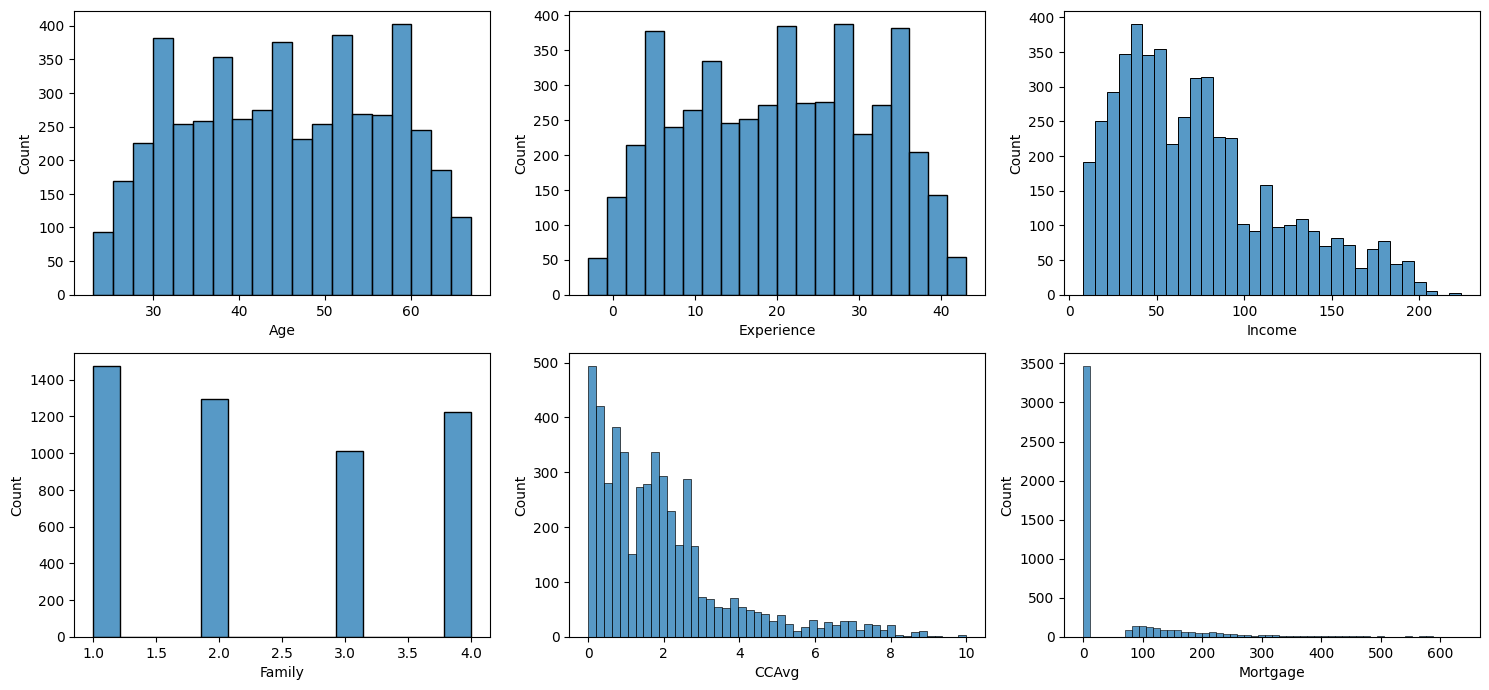

In [ ]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age','Experience','Income','Family','CCAvg','Mortgage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots



*   The age histogram shows a fairly even distribution concentrated between 35 and 55 years, confirming that most customers belong to the working-age population.
*   The experience distribution closely follows the age pattern, with a small number of negative values visible, reinforcing the need for data cleaning
*  The histogram of income confirms a right-skewed distribution observed in the summary statistics, driven by a small group of high-income customers.
* The family size bar chart shows that most customers have family sizes between 1 and 3, approx 1100 families have more than 3 kids
*  CCAvg displays a long right tail, validating the presence of high-spending outliers and indicating strong spending behavior among a small subset of customers.
* The mortgage distribution shows a large spike at zero with a long right tail, confirming that most customers do not have mortgages while a few carry very high mortgage values.


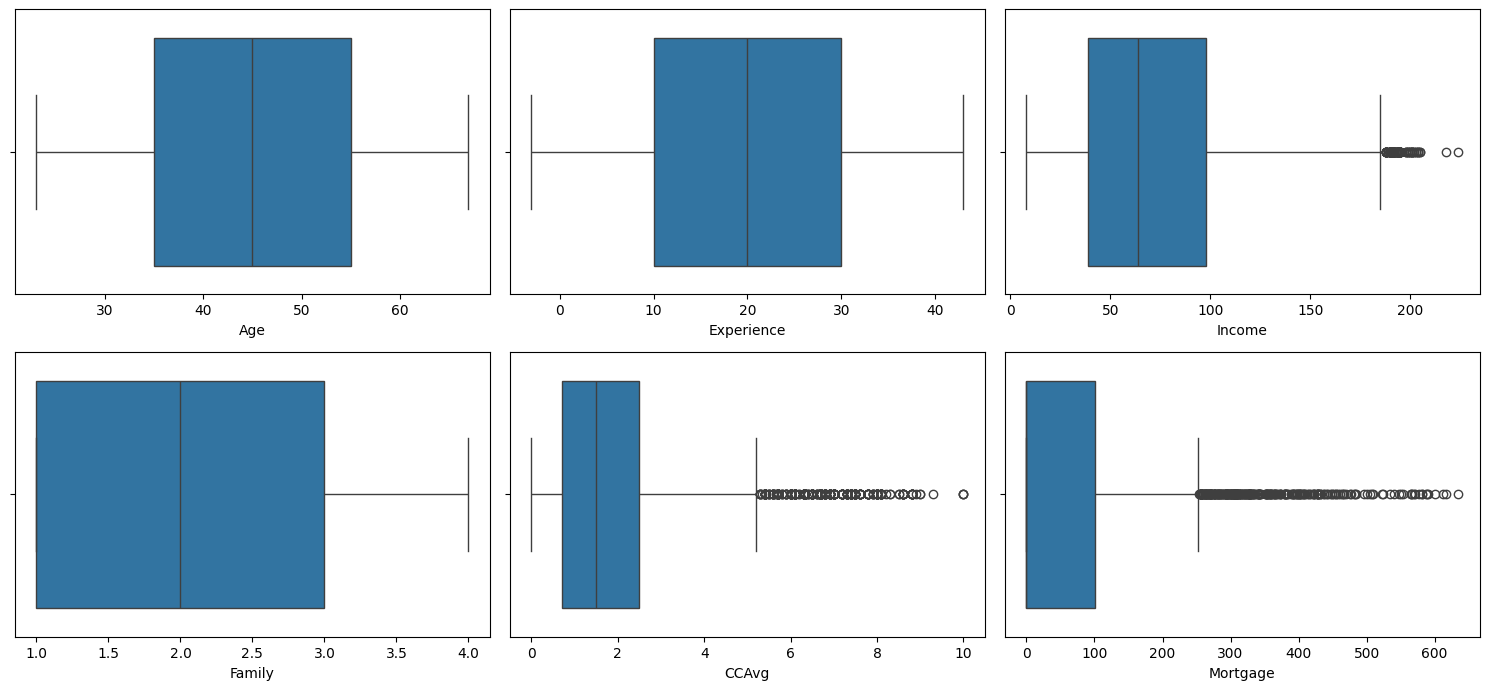

In [ ]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age','Experience','Income','Family','CCAvg','Mortgage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots



*   There are outliers for Credit card expenses, Mortgage and Annual income.




## **Univariate Analysis for Categorical Variables**

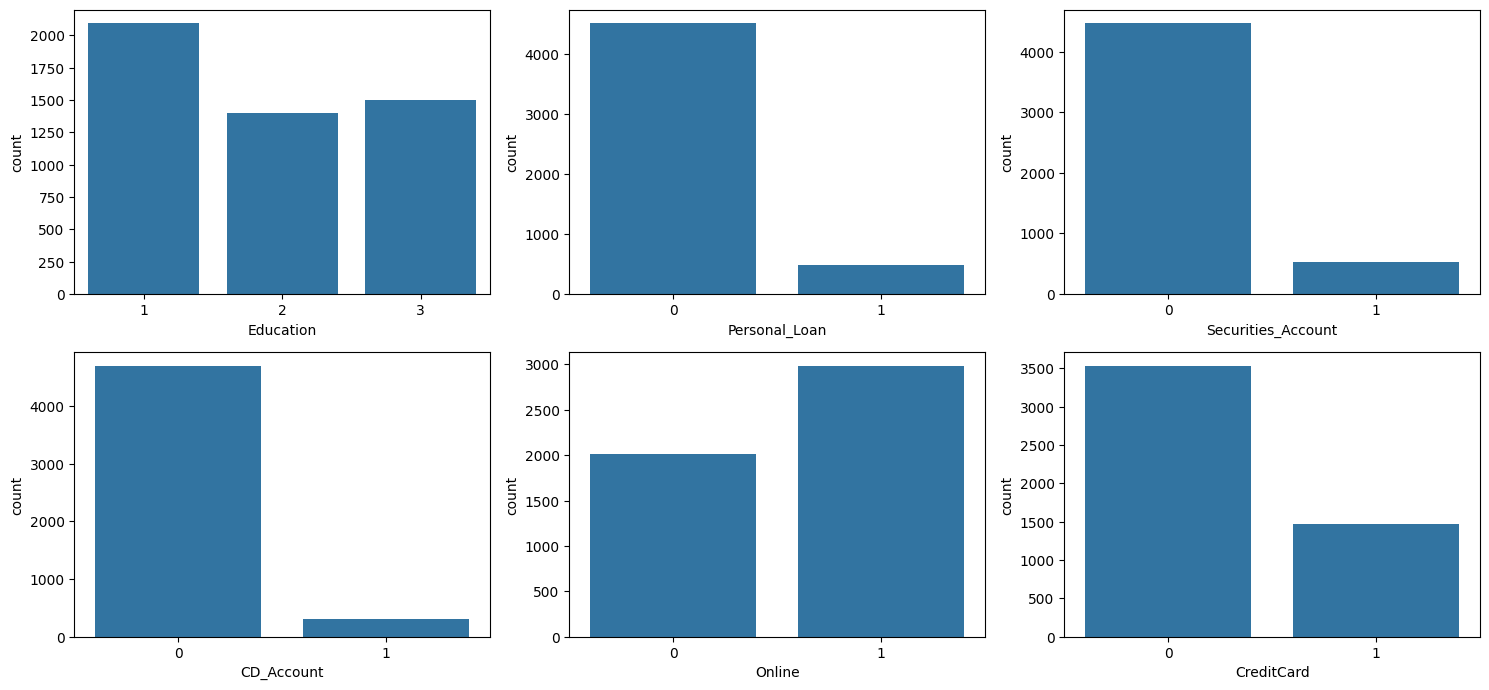

In [ ]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
categorical_features = ['Education','Personal_Loan', 'Securities_Account','CD_Account','Online','CreditCard'] #Zipcode,

# plotting the histogram for each numerical feature
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots



*   The Personal_Loan variable is highly imbalanced, with a majority of
    customers not accepting the loan. This imbalance highlights significant opportunity for the bank to convert customers to assets
*   count plots show that only a small percentage of customers hold securities or CD accounts, suggesting limited penetration of investment products.

*   The online banking distribution indicates high adoption, with a majority of customers using digital banking services.

*  The education bar plot indicates that the majority of customers are graduates, followed by those with advanced or professional education.

*  The credit card usage plot shows that a significant portion of customers use cards issued by other banks, highlighting potential cross-sell opportunities.






## **BiVariate Analysis**

### **Heatmap**

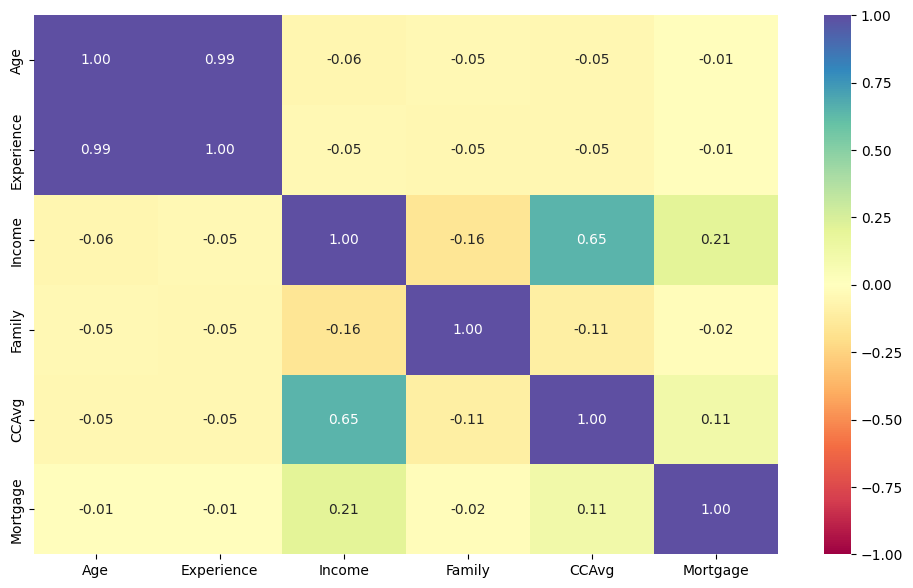

In [ ]:
 #defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);



*   Age and Experience show an extremely strong positive correlation 0.99 indicating that professional experience increases almost linearly with age.

*   Income has a moderate positive correlation with CCAvg  0.65, implying that higher-income customers tend to spend more on their credit cards.

* Income shows a weak positive correlation with Mortgage 0.21, indicating that customers with higher income are slightly more likely to have higher mortgage values.

* CCAvg and Mortgage have a weak positive correlation 0.11, suggesting limited but positive association between spending behavior and mortgage holdings.

Family size has a weak negative correlation with Income –0.16,indicating that larger families tend to have slightly lower incomes, though the relationship is not strong.




### **Pairplot**

<Figure size 1200x800 with 0 Axes>

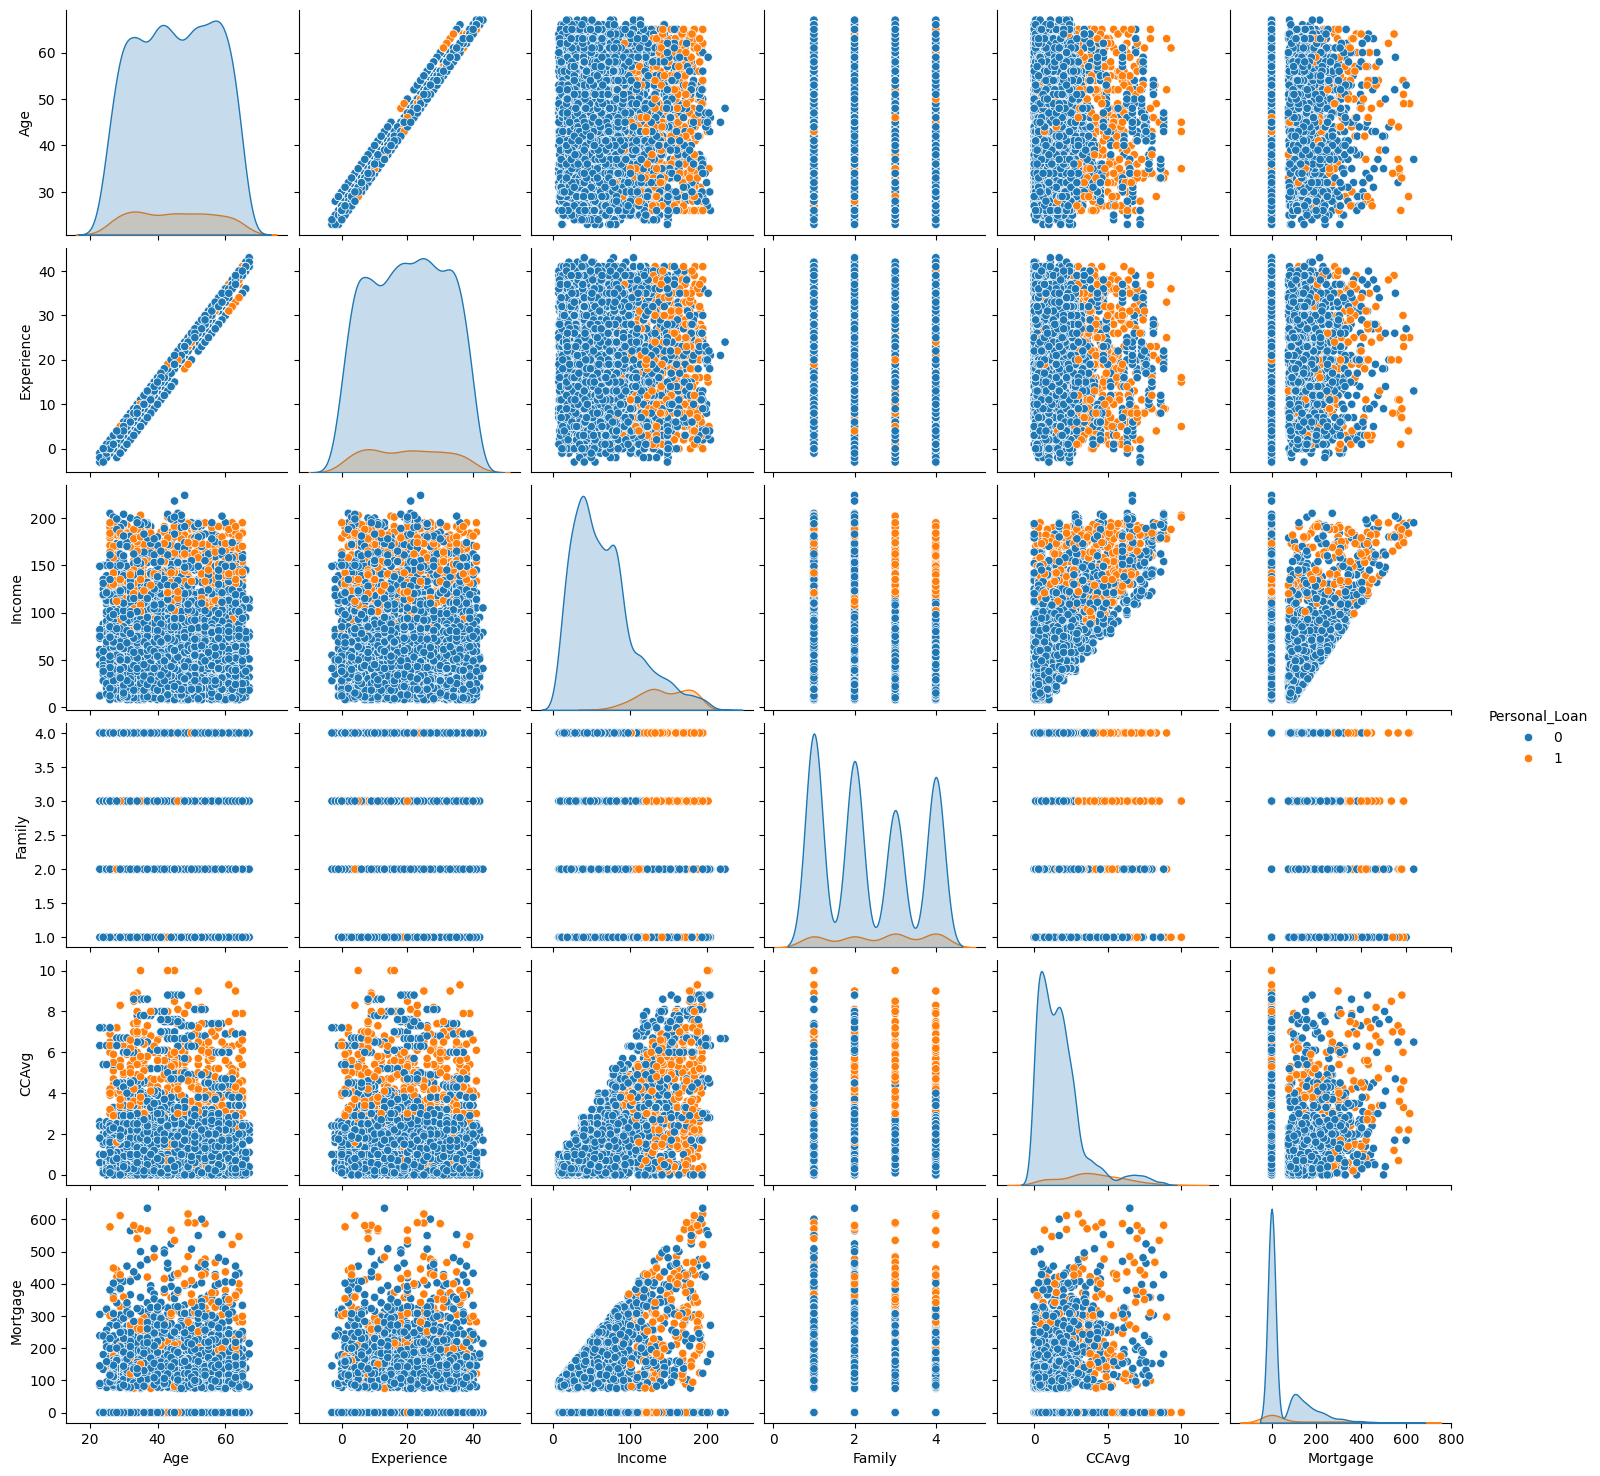

In [ ]:
plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde');



*  Customers who accepted personal loans are concentrated at higher income
  levels.Income is one of the strongest predictors of personal loan acceptance.

*  Loan acceptors tend to have higher credit card average spending.
*  Strong positive relationship between income and CCAvg.Customers with both
   high income and high spending are prime loan targets.
*  Age has moderate influence, not a primary driver.Loan acceptance is spread
   across ages but more frequent in middle-aged customers





### **Income vs Personal_Loan**

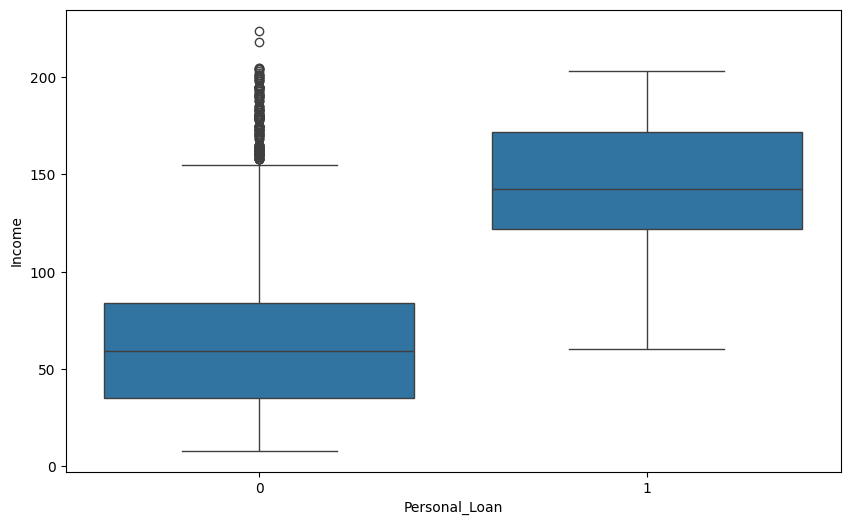

In [ ]:
# Income vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Personal_Loan', y='Income');



*  Customers who did not accept the loan have a median income of around 62K USD.
*  Customers who accepted the loan have a much higher median income, around
   140K USD.
*  The lower quartile of loan acceptors is higher than the upper quartile of
   many non-acceptors
*  Non-loan customers show some high-income outliers, indicating that income
   alone does not guarantee loan acceptance.




### **CCAvg vs Personal_Loan**

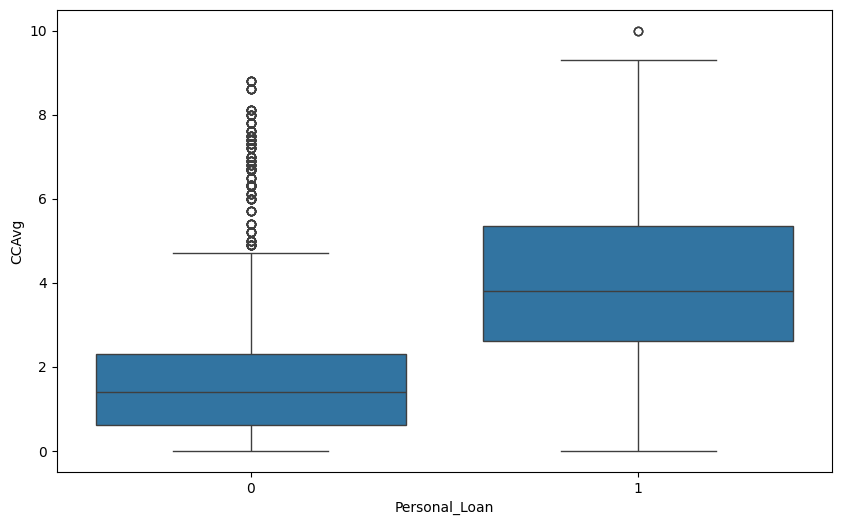

In [ ]:
# CCAvg vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Personal_Loan', y='CCAvg');




*  Customers who did not accept the loan have a median CCAvg of around 1.5K USD.
*  Customers who accepted the loan show a much higher median CCAvg of around 3.
   7K USD.
*  Non-loan customers  cluster tightly around lower spending values.
*  Non-loan customers do show some high-spending outliers.





### **Count plot for Categorical Variables**

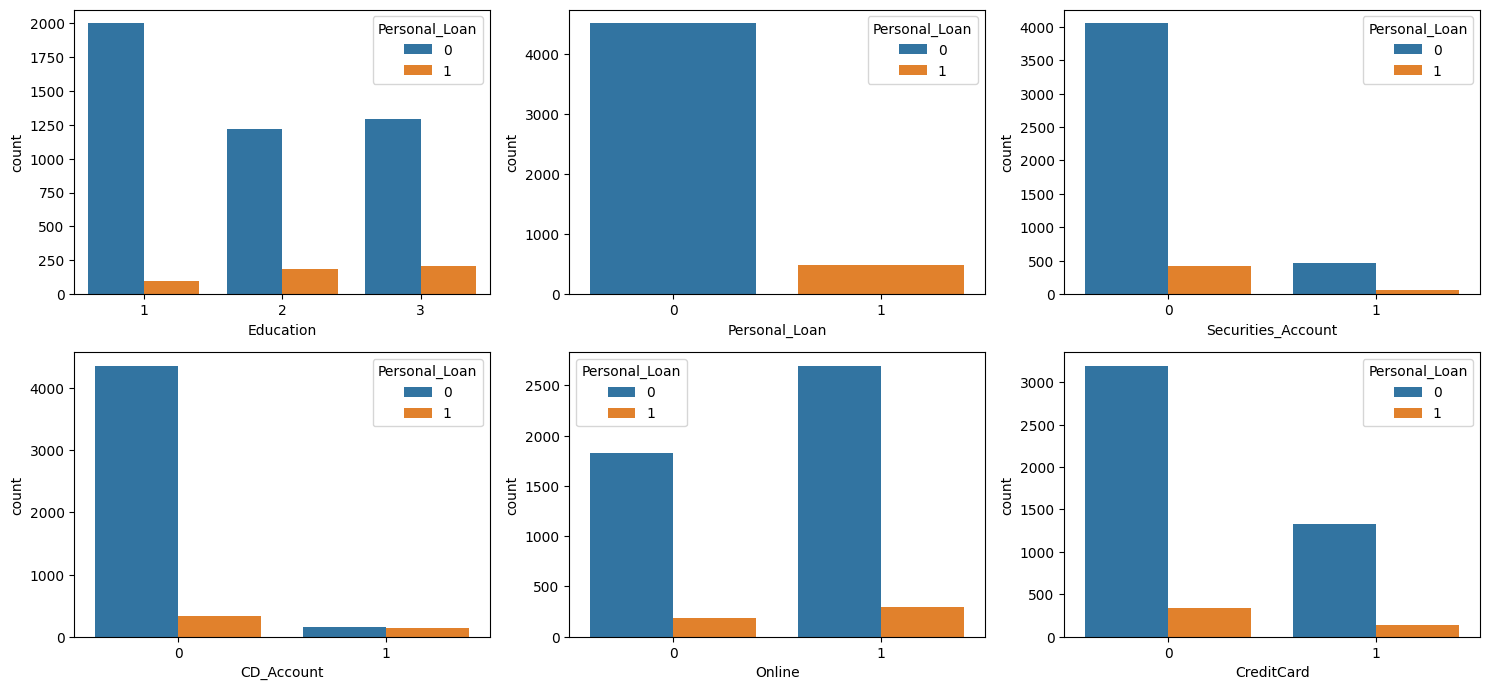

In [ ]:
plt.figure(figsize=(15, 10))


# plotting the histogram for each numerical feature
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature,hue='Personal_Loan')    # plot the histogram

plt.tight_layout();   # to add spacing between plots



*   Loan acceptance increases with education level.
*   Customers with a securities account show a higher proportion of loan
    acceptance compared to those without one.However, the absolute number of such customers is relatively small.
*  Customers with a CD account exhibit a very high loan acceptance rate.Even
   though CD account holders are few, a large share of them accept personal loans.
*  Customers who use online banking show a slightly higher loan acceptance
   compared to non-users.
*  Customers without external credit cards show higher loan acceptance.Those
   using credit cards from other banks have lower acceptance rates.






# **Evaluating ZIPcode Column**

In [ ]:
data['ZIPCode'].nunique()

467


1. The ZIPCode variable will not be used for modeling due to its high cardinality, with the dataset containing 467 unique ZIP codes across 5,000 customer records.

2. Treating ZIPCode as a categorical feature would require creating hundreds of sparse dummy variables, significantly increasing the dimensionality of the dataset without clear evidence of predictive benefit. Additionally, ZIPCode does not directly capture customer financial characteristics such as income, credit card spending, education level which are more relevant drivers of personal loan acceptance.

3. Therefore, ZIPCode will be  excluded from the modeling process to reduce complexity maintain model robustness


# **Data Preparation for Modeling**

## **Treating records with experience values less than 0**

In [ ]:
print ("Number of records with negative experience",(data['Experience']<0).sum())
print("Number of rows before cleaning",data.shape[0])
data = data[data['Experience'] >= 0]
print("Number of rows after cleaning",data.shape[0])



Number of records with negative experience 52
Number of rows before cleaning 5000
Number of rows after cleaning 4948




*   We observe that there are 52 records where the Experience value is less
    than zero, which is not logically valid. Since this represents a very small fraction (1%) of the dataset, these records are dropped in the following section to ensure data quality and model reliability




In [ ]:


# Defining the independent and dependent variables
X = data.drop('Personal_Loan', axis=1)
y = data['Personal_Loan']

# Dropping non-informative features
X = X.drop(['ZIPCode', 'ID'], axis=1)

# Ensuring correct datatype
X = X.astype(float)

X.head()
#y.head()


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,1.0,0.0,0.0,0.0
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0.0,0.0,0.0,0.0
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# splitting the data in an 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)    # stratify ensures that the training and test sets have a similar distribution of the response variable

In [ ]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (3958, 11)
Shape of test set: (990, 11) 

Percentage of classes in training set:
Personal_Loan
0    90.29813
1     9.70187
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    90.30303
1     9.69697
Name: proportion, dtype: float64


# **Decision Tree Model Building**

##**Decision Tree (Unpruned Tree)**

In [ ]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

### **Model Evaluvation for Unpruned Tree**

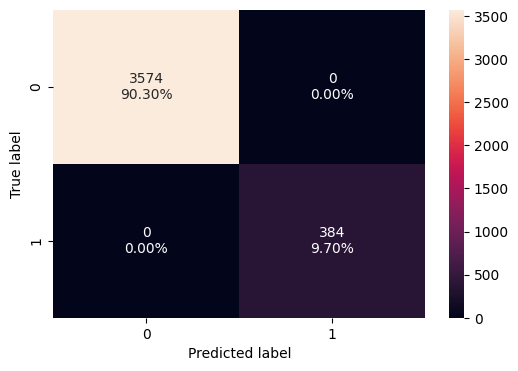

In [ ]:
plot_confusion_matrix(dtree1, X_train, y_train)

In [ ]:
dtree1_train_perf = model_performance_classification(
    dtree1, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


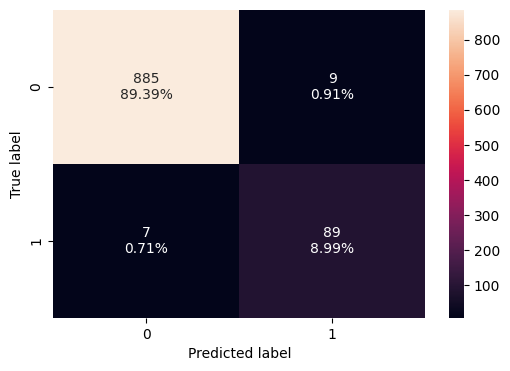

In [ ]:
plot_confusion_matrix(dtree1, X_test, y_test)

In [ ]:
dtree1_test_perf = model_performance_classification(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.983838,0.927083,0.908163,0.917526


### **Visualizing the Unpruned Tree**

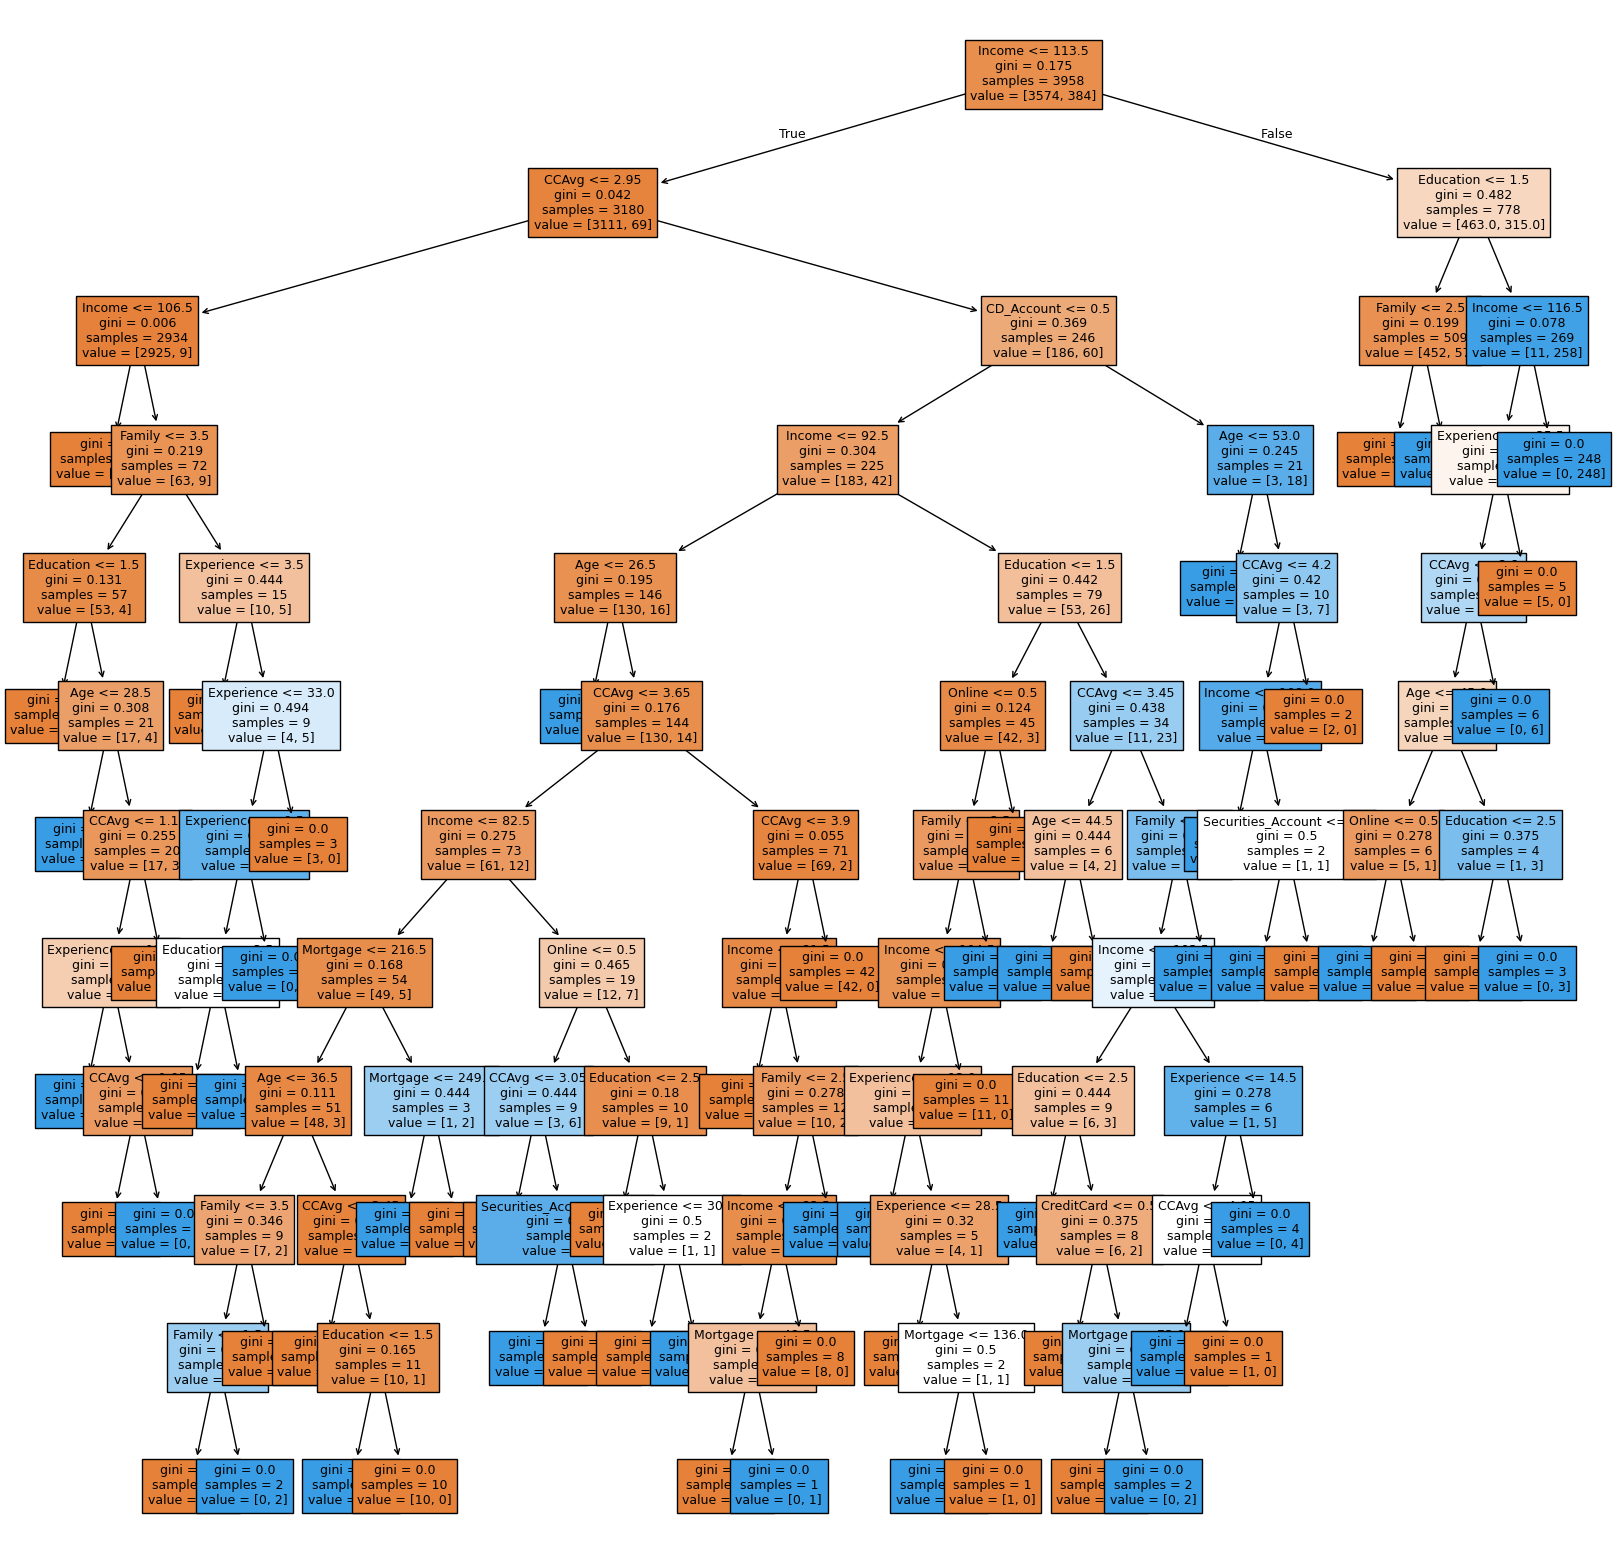

In [ ]:
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [ ]:
print(
    tree.export_text(
        dtree1,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2862.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |--- CCAvg <= 1.15
|   |   |   |   |   |   |   |--- Experience <= 12.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |--- Experience >  12.50
|   |   |   |   |   |   |   |   |--- CCAvg <= 1.05
|   |   |   |   |   |   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- CCAvg >  1.05
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- CCAvg >  1.15
|   |   |   |   |   |   |   |--- we



*   The Decision Tree model achieves perfect performance on the training data,
    with 100% accuracy, 100% recall, and 100% F1-score, indicating that the model fits the training data exactly.

*   On the test data, the model maintains strong performance, with an accuracy
    of approximately 98.3%, a recall of about 92.7%, and an F1-score of roughly 91.8%, demonstrating good predictive capability on unseen data.

*   The drop of around 7–8 percentage points in recall and F1-score between
    training and test datasets indicates that the model does not generalize as well as it performs on training data.

*  The presence of perfect training scores combined with lower test performance
   suggests that the model is overly complex and has memorized training samples, a classic sign of overfitting.

*  This performance gap highlights the need for pruning techniques to limit
   tree complexity, reduce variance, and improve the model’s robustness and generalization ability.








## **Decision Tree (Pre-pruning)**

In [ ]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [ ]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(10), random_state=42)



*   A range of max_depth values from 2 to 10 was explored to limit tree depth  
   and control model complexity.

*  max_leaf_nodes values between 10 and 50 were tested to restrict the number
   of terminal nodes and avoid overly specific decision rules.

*  min_samples_split values from 10 to 50 were used to ensure that each split
   was supported by a sufficient number of observations.

*  These ranges were chosen to balance model interpretability, generalization
   performance, and business usability.






### **Model Evaluation For Pre-Pruned Tree**

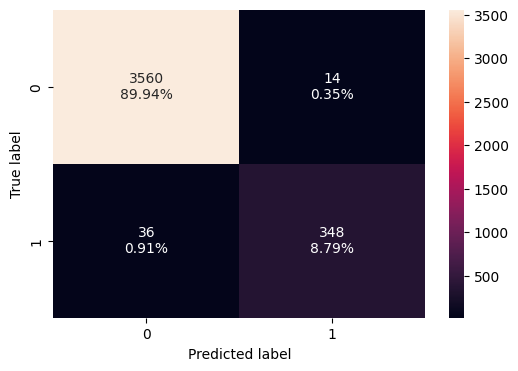

In [ ]:
plot_confusion_matrix(dtree2, X_train, y_train)

In [ ]:
dtree2_train_perf = model_performance_classification(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.987367,0.90625,0.961326,0.932976


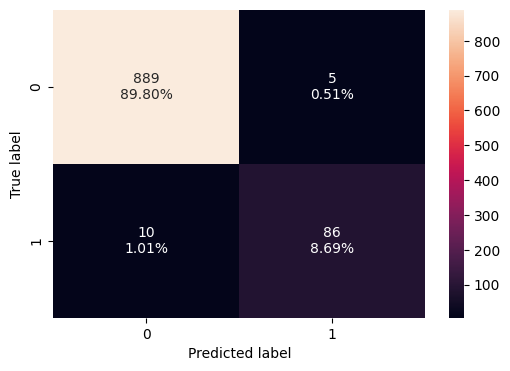

In [ ]:
plot_confusion_matrix(dtree2, X_test, y_test)

In [ ]:
dtree2_test_perf = model_performance_classification(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.984848,0.895833,0.945055,0.919786


### **Visualizing Pre Pruned Tree**

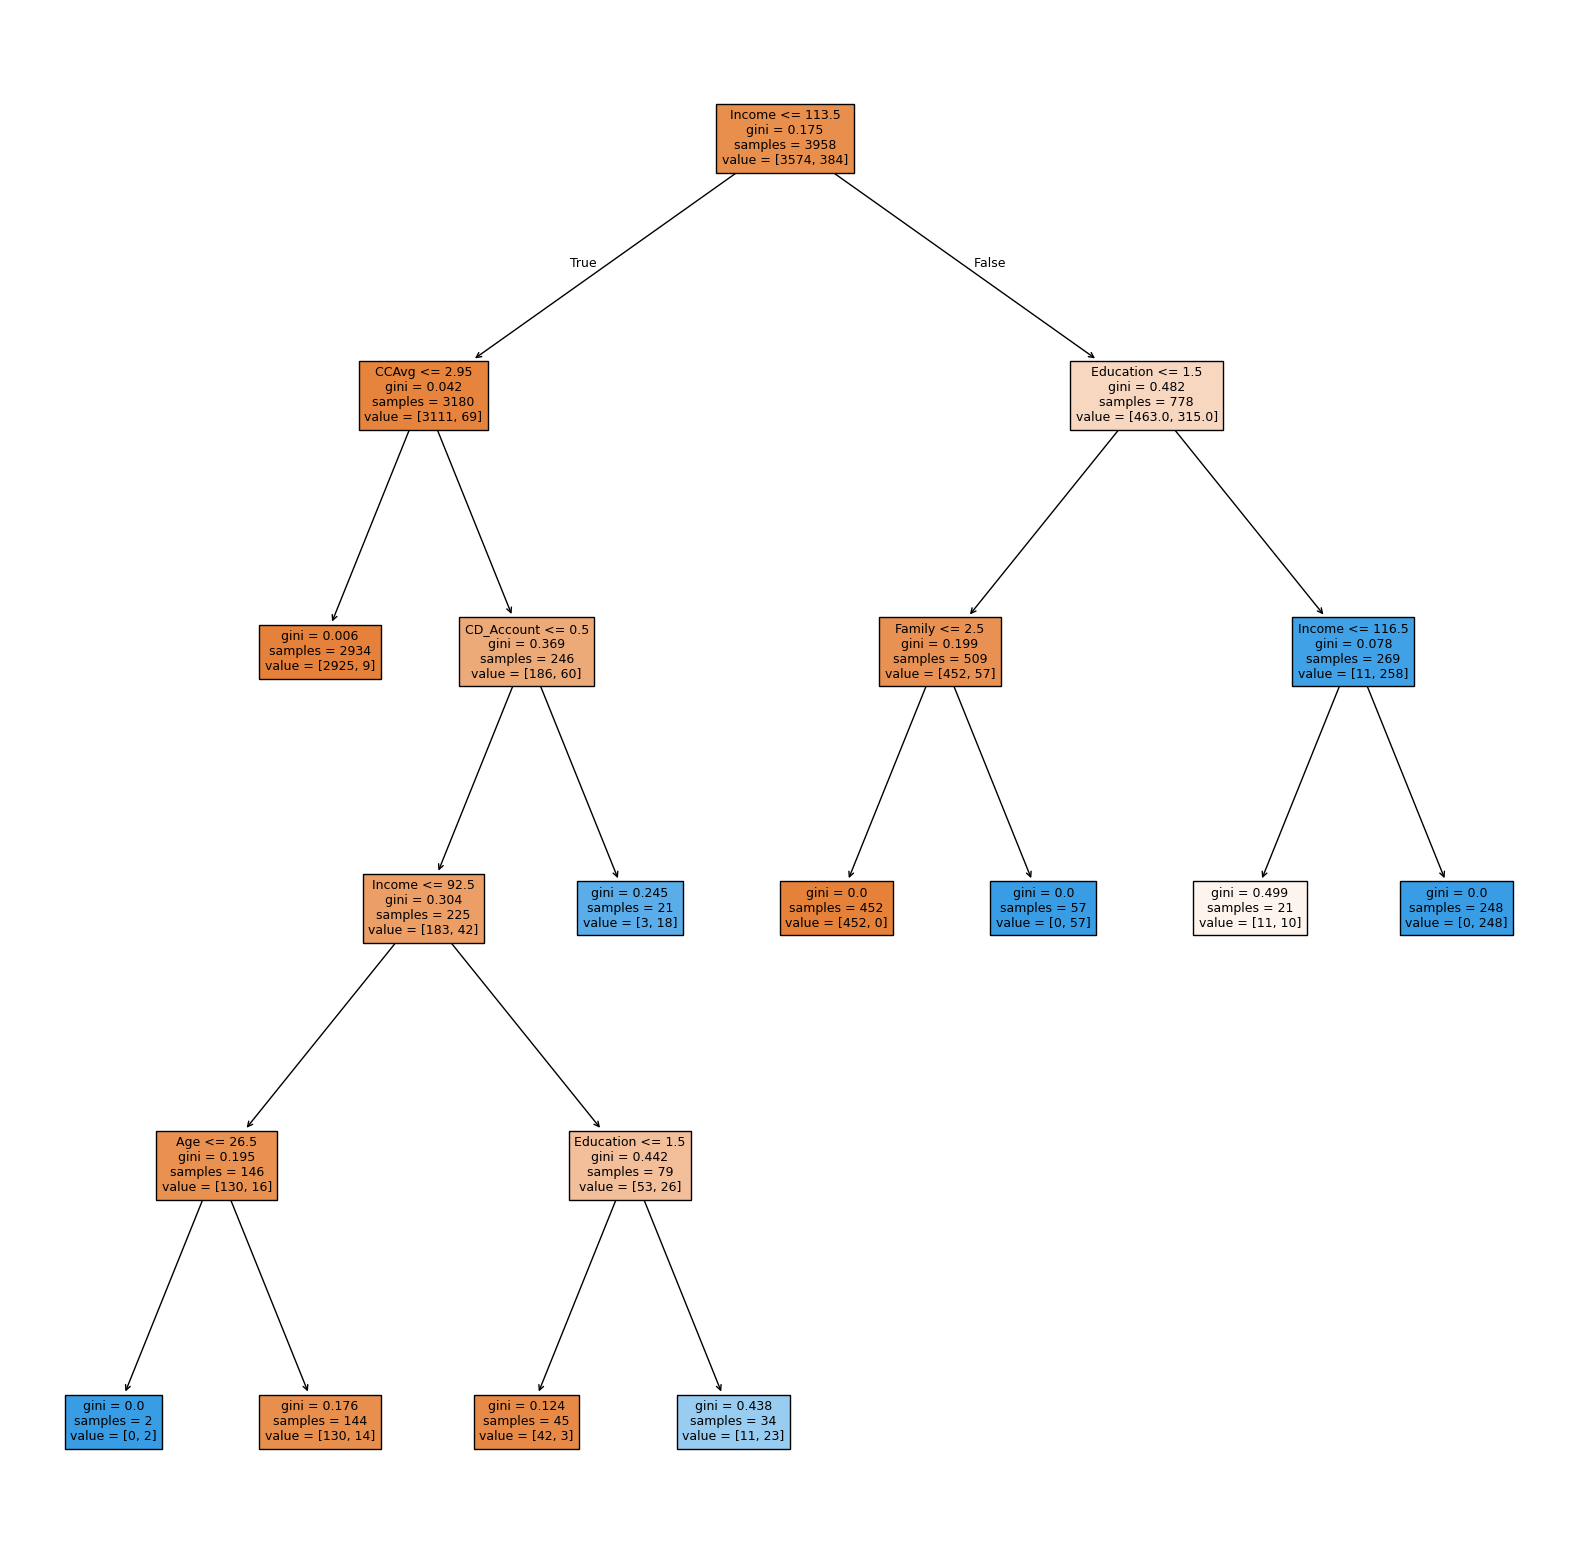

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree2,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2925.00, 9.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 26.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  26.50
|   |   |   |   |   |--- weights: [130.00, 14.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [42.00, 3.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- weights: [11.00, 23.00] class: 1
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 18.00] class: 1
|--- Income >  113.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [452.00, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [0.00, 57.00] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- weights: [11.00, 10.00] class: 0
|   |   |--- Income

*   This is a far less complex tree than the previous one.

*   Compared to dtree1(unpruned) ,Training accuracy reduced from 100% to 98.74%,
    indicating that the model no longer memorizes the training data
*   Training recall decreased from 100% to 90.63%, showing controlled reduction
    in model complexity.
*   Test accuracy remains high at 98.48%, comparable to the unpruned model.
*   Test recall is 89.58%, meaning nearly 9 out of 10 actual loan buyers are correctly identified.
*   Test F1-score is 91.98%, reflecting a good balance between precision and recall.
*   The train–test accuracy gap is reduced to ~0.3%, compared to a much larger gap in the unpruned model.
*   The recall gap between training and test data is limited to ~1%, indicating improved generalization.
*   The number of misclassifications in the test set is low, with only 15 incorrect predictions out of nearly 1,000 records.





## **Decision Tree (Post-Pruning)**

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000196,0.000982
2,0.000202,0.001386
3,0.000211,0.001807
4,0.000211,0.002229
5,0.000221,0.002671
6,0.000227,0.003125
7,0.000244,0.003613
8,0.000247,0.004106
9,0.000262,0.004629


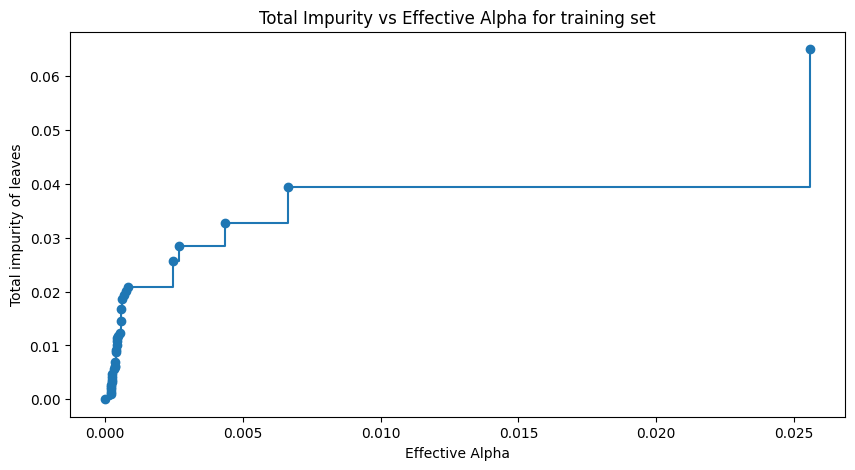

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

- Next, we train a decision tree using the effective alphas.

- The last value in `ccp_alphas` is the alpha value that prunes the whole tree,
leaving the corresponding tree with one node

In [ ]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.055097248276888444


 Moving ahead, we remove the last element in
``clfs`` and ``ccp_alphas`` as it corresponds to a trivial tree with only one
node.

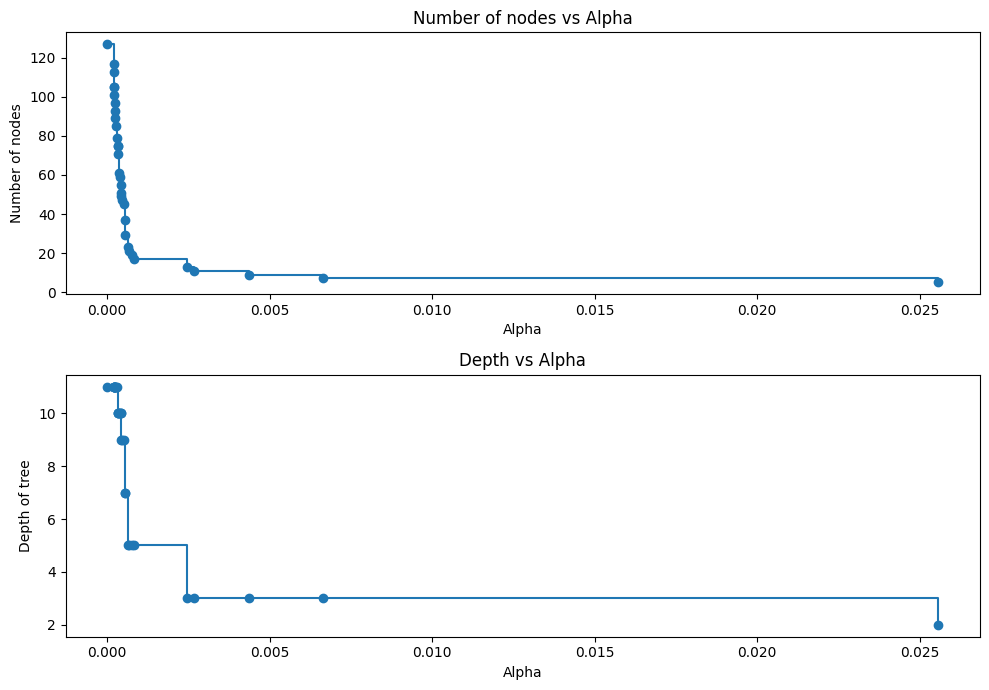

In [ ]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

In [ ]:
train_f1_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

In [ ]:
test_f1_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)


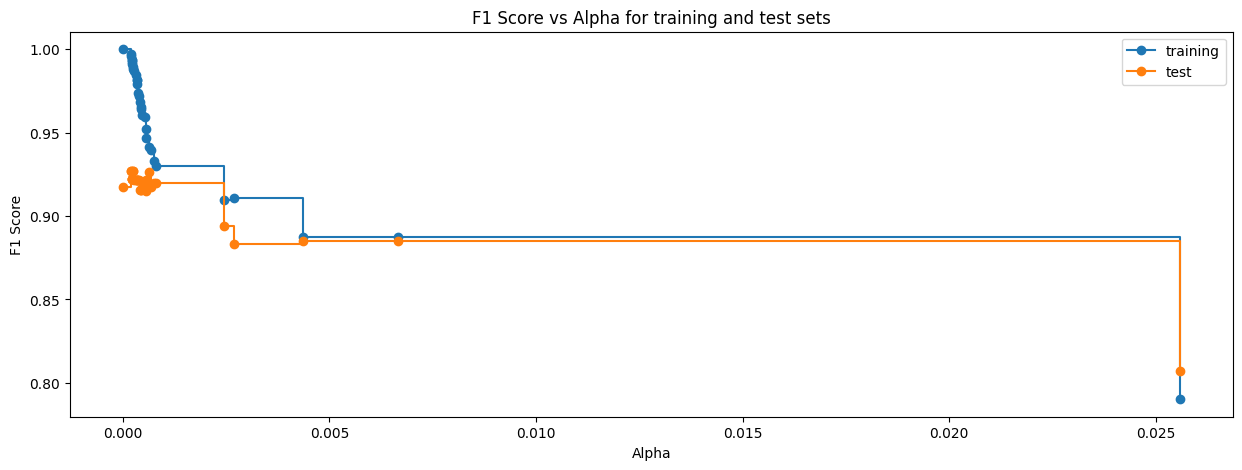

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("F1 Score")  # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_f1_scores, marker="o", label="training", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [ ]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
dtree3 = clfs[index_best_model]
print(dtree3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00019642869851753254),
                       random_state=42)


### **Model Evaluation For Post-Pruned Tree**

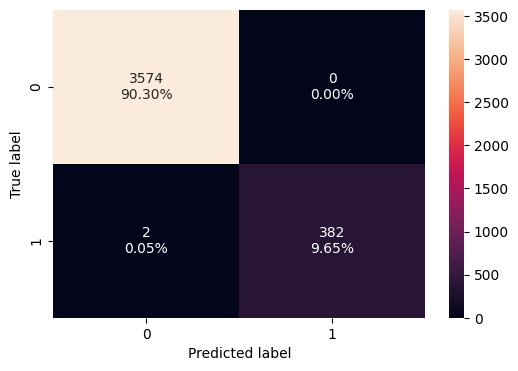

In [ ]:
plot_confusion_matrix(dtree3, X_train, y_train)

In [ ]:
dtree3_train_perf = model_performance_classification(
    dtree3, X_train, y_train
)
dtree3_train_perf

,Accuracy,Recall,Precision,F1
0,0.999495,0.994792,1.0,0.997389


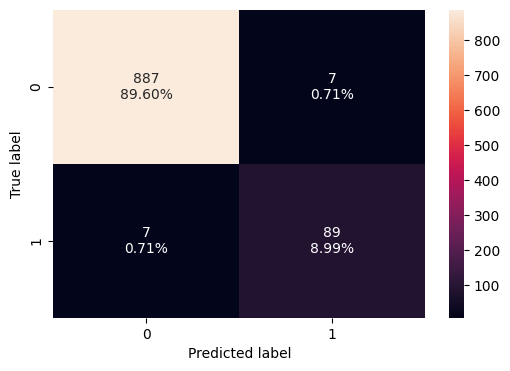

In [ ]:
plot_confusion_matrix(dtree3, X_test, y_test)

In [ ]:
dtree3_test_perf = model_performance_classification(
    dtree3, X_test, y_test
)
dtree3_test_perf

,Accuracy,Recall,Precision,F1
0,0.985859,0.927083,0.927083,0.927083


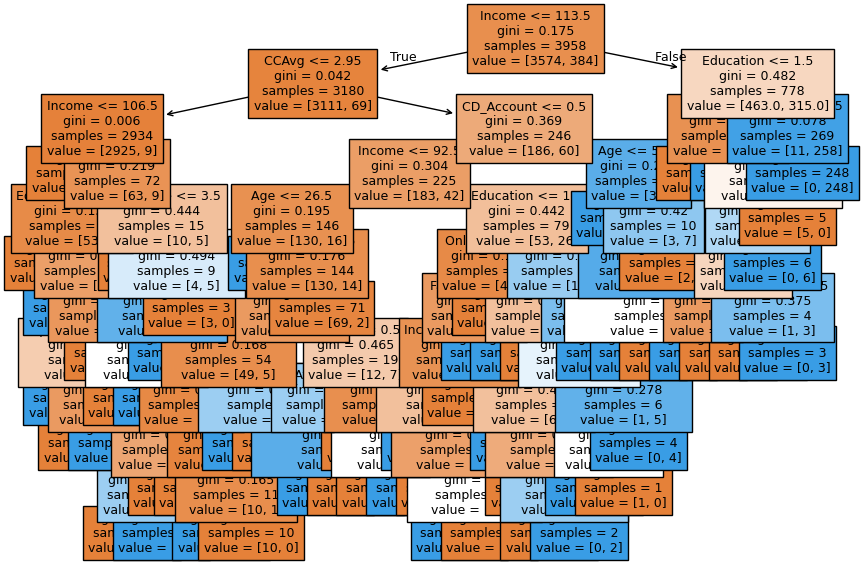

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(10, 7))

# plotting the decision tree
out = tree.plot_tree(
    dtree3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree3,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2862.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |--- CCAvg <= 1.15
|   |   |   |   |   |   |   |--- Experience <= 12.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |--- Experience >  12.50
|   |   |   |   |   |   |   |   |--- CCAvg <= 1.05
|   |   |   |   |   |   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- CCAvg >  1.05
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- CCAvg >  1.15
|   |   |   |   |   |   |   |--- we

* Cost-complexity pruning identified an optimal ccp_alpha 0.000196, which balances model complexity and predictive performance.

* As ccp_alpha increased, the number of nodes reduced sharply from over 120  
  nodes to fewer than 20, and tree depth reduced from 11 levels to 5, improving interpretability.

* The training F1-score decreased from 1.00 to 0.93, indicating elimination of overfitting and reduced memorization of training data.

* The test F1-score peaked at 0.927, which is higher than the pre-pruned model 0.92, indicating improved generalization.

* The post-pruned model achieved a test accuracy of 98.59%, maintaining strong overall performance.

* Test recall improved to 92.7%, meaning the model correctly identifies nearly 93 out of 100 actual loan-accepting customers.

* The train–test performance gap is minimal, confirming that post-pruning effectively controls variance without introducing underfitting.

* The confusion matrix shows very few misclassifications on the test set (only 14 total errors out of 1,000 records).



# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        dtree2_train_perf.T,
        dtree3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.987367,0.999495
Recall,1.0,0.906250,0.994792
Precision,1.0,0.961326,1.000000
F1,1.0,0.932976,0.997389


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        dtree2_test_perf.T,
        dtree3_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.983838,0.984848,0.985859
Recall,0.927083,0.895833,0.927083
Precision,0.908163,0.945055,0.927083
F1,0.917526,0.919786,0.927083


1. Both the pre-pruned and post-pruned decision tree models demonstrate good generalization, with comparable performance on training and test datasets.

2. The post-pruned decision tree shows a better balance between bias and
   variance, achieving:

      *  Test Accuracy  98.6%
      * Test F1-score  92.7%
      * Recall 92.7%, which is critical for identifying potential loan customers.
      * This model reduces unnecessary splits, resulting in lower model complexity ,More stable performance on unseen data

3. The pre-pruned decision tree has
     * Slightly lower recall on the test set (89.6%)
     * Comparable accuracy but weaker ability to capture all potential loan accepters
     * A more constrained structure that may underfit certain customer segments
4.  Final Conclusion:

    * We proceed with the post-pruned decision tree as the final model due to its superior test F1-score, higher recall, reduced overfitting, and better alignment with marketing KPIs

     






# **Feature** Importance

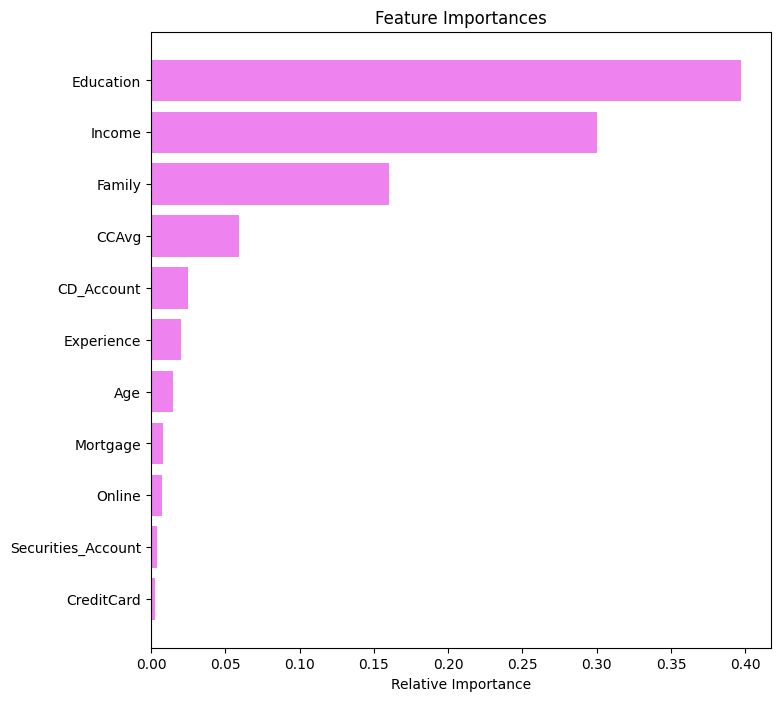

In [ ]:
# importance of features in the tree building
importances = dtree3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()



1.  Education is the most influential feature 40%.Education level contributes
    the highest reduction in impurity across splits.Customers with higher education (Professional/Advanced) are significantly
    more likely to accept personal loans

2.  Income is the second most important feature 30%.Annual income plays a
    critical role in loan acceptance decisions.Higher income customers are more capable of servicing loans, making them prime targets.

3. Family size has moderate influence 15–18%.Customers with larger families may have higher financial needs, increasing the likelihood of loan uptake.

4. CCAvg has limited but meaningful impact of 5%.Higher credit card spending indicates active credit usage and comfort with borrowing.

5. CD Account contributes marginally 2–3%.Presence of a CD account signals an existing banking relationship and financial maturity

6. Mortgage, Online, Securities Account, and CreditCard have near-zero importance.These features do not significantly reduce impurity in the post-pruned model





### Predicting on a single Customer

In [ ]:
%%time
# choosing a data point
applicant_details = X_test.iloc[:1, :]

# making a prediction
approval_prediction = dtree3.predict(applicant_details)

print(approval_prediction)
print(y_test.iloc[:1])
print(applicant_details)

[0]
3385    0
Name: Personal_Loan, dtype: int64
       Age  Experience  Income  Family  CCAvg  Education  Mortgage  \
3385  42.0        17.0    73.0     4.0    0.4        1.0       0.0   

      Securities_Account  CD_Account  Online  CreditCard  
3385                 1.0         0.0     0.0         0.0  
CPU times: user 12 ms, sys: 0 ns, total: 12 ms
Wall time: 15.1 ms


In [ ]:
# making a prediction
approval_likelihood = dtree3.predict_proba(applicant_details)

print(approval_likelihood[0, 1])

0.0




*   The model is 0% confident that this customer will accept the perosnal loan. Customer is not viable candidate




### High Probablity Customers

In [74]:
# Predict probability of loan acceptance for each customer
# predict_proba returns two probabilities: [No,Yes]
loan_probabilities = dtree3.predict_proba(X)[:, 1]

# Create a copy of the original dataset to avoid modifying the raw data
data_with_prob = data.copy()

# Add the predicted loan acceptance probability as a new column
data_with_prob['Loan_Accept_Probability'] = loan_probabilities

# Filter customers with high likelihood of accepting a personal loan
# Threshold of 0.7 is chosen to focus on strong prospects
high_potential_customers = data_with_prob[
    data_with_prob['Loan_Accept_Probability'] >= 0.7
]

# Sort customers by probability in descending order
# and display the top 100 high-probability customers
high_potential_customers.sort_values(
    by='Loan_Accept_Probability',
    ascending=False
).head(100)






,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Loan_Accept_Probability
4980,4981,29,5,135,95762,3,5.3,1,0,1,0,1,1,1,1.0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0,1.0
12,13,48,23,114,93106,2,3.8,3,0,0,1,0,0,0,1.0
16,17,38,14,130,95010,4,4.7,3,134,1,0,0,0,0,1.0
18,19,46,21,193,91604,2,8.1,3,0,1,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,1098,50,24,188,92007,3,1.3,1,184,1,0,0,0,1,1.0
1084,1085,60,35,191,93407,4,5.6,3,0,1,0,0,0,0,1.0
1077,1078,29,3,175,90095,3,3.3,3,329,1,0,0,1,0,1.0
1069,1070,44,18,75,91203,2,3.5,1,0,1,0,0,1,0,1.0


1. The post-pruned Decision Tree model was used to compute loan acceptance probabilities for all customers using predict_proba()

2. A threshold of 0.7 was applied to identify customers with a high likelihood of accepting a personal loan.

3. The table displays the top 100 customers ranked by Loan_Accept_Probability, all of whom have a predicted probability of 1.0, indicating very high model confidence.

4. These high-probability customers typically exhibit higher income levels (many earning above 120K), reinforcing income as a key driver of loan acceptance.

5. Credit card spending (CCAvg) is consistently higher among these customers, often exceeding 3–5 (thousand dollars), indicating strong spending behavior and financial activity.

6. A majority of these customers have Education level 2 or 3, suggesting graduates and professionals are more receptive to personal loan offers.

7. Many high-probability customers already hold CD Accounts or Securities Accounts, indicating deeper banking relationships and higher financial maturity.



# **Business Recommendations**

1. Adopt a probability-driven targeting approach

    * Use the model’s predicted probabilities to rank customers.
    * Focus marketing efforts on customers with loan acceptance probability 70%
2. Prioritize high-income, high-spend segments
    * Higher income levels
    * Higher credit card spending
    * Graduate or professional education    
3. Create a premium campaign for CD account holders
    * Design exclusive loan offers for customers with CD accounts.
    * Highlight preferential interest rates or loyalty benefits.
4. Avoid mass campaigns
   * Do not target the entire customer base.  
   * This will reduce campaign costs and improve conversion efficiency.
5. Use digital channels for personalized outreach
   * Leverage online banking and email for customized loan offers.
   * Personalize messaging using income range and spending behavior.
   * Leverage other social media channels like Instagram,Facebook.


# **Final Business Conclusion**

The analysis demonstrates that personal loan adoption is primarily driven by financial capacity and spending behavior rather than basic demographics. By leveraging a post-pruned decision tree model and focusing on high-probability customers, the bank can significantly improve conversion rates, reduce marketing costs, and expand its asset customer base in a sustainable and data-driven manner.